In [1]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import math
import glob

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import model_from_json
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model

import sklearn 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.utils import class_weight

import IvysaurusModel_VGG
import IvysaurusModel

import FileHelper

In [2]:
dimensions = 24
nClasses = 5

useCaloModel = True
useDispModel = False
useTrackVars = True
useShowerVars = True 

nTrackVars = 10 # nTrackChildren, nShowerChildren, nGrandChildren, nChildHits, childEnergy, childTrackScore, trackLength, trackWobble, trackScore, momComparison
nShowerVars = 16 # displacement, dca, trackStubLength

In [3]:
startGridU_calo_test = np.empty((0, dimensions, dimensions, 1))
startGridV_calo_test = np.empty((0, dimensions, dimensions, 1))
startGridW_calo_test = np.empty((0, dimensions, dimensions, 1))

endGridU_calo_test = np.empty((0, dimensions, dimensions, 1))
endGridV_calo_test = np.empty((0, dimensions, dimensions, 1))
endGridW_calo_test = np.empty((0, dimensions, dimensions, 1))

startGridU_disp_test = np.empty((0, dimensions, dimensions, 1))
startGridV_disp_test = np.empty((0, dimensions, dimensions, 1))
startGridW_disp_test = np.empty((0, dimensions, dimensions, 1))

endGridU_disp_test = np.empty((0, dimensions, dimensions, 1))
endGridV_disp_test = np.empty((0, dimensions, dimensions, 1))
endGridW_disp_test = np.empty((0, dimensions, dimensions, 1))

# Track and shower vars
trackVars_test = np.empty((0, nTrackVars))
showerVars_test = np.empty((0, nShowerVars))

y_test = np.empty((0, nClasses))

trainFileNames = glob.glob('/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/*/ivysaurus_*.npz')
#trainFileNames = glob.glob('/Users/isobel/Desktop/DUNE/Ivysaurus/IvysaurusCaloDisp/test/nu_dune10kt_1x2x6_1413_86_20230826T183315Z_gen_g4_detsim_hitreco_IvysaurusTrainingFiles.npz')
print(trainFileNames)

for trainFileName in trainFileNames :
    print('Reading file: ', str(trainFileName),', This may take a while...')
    
    data = np.load(trainFileName)

    # Calo grids
    if (useCaloModel) :
        startGridU_calo_test = np.concatenate((startGridU_calo_test, data['startGridU_calo_test']), axis=0)
        startGridV_calo_test = np.concatenate((startGridV_calo_test, data['startGridV_calo_test']), axis=0) 
        startGridW_calo_test = np.concatenate((startGridW_calo_test, data['startGridW_calo_test']), axis=0)
    
        endGridU_calo_test = np.concatenate((endGridU_calo_test, data['endGridU_calo_test']), axis=0)
        endGridV_calo_test = np.concatenate((endGridV_calo_test, data['endGridV_calo_test']), axis=0)
        endGridW_calo_test = np.concatenate((endGridW_calo_test, data['endGridW_calo_test']), axis=0)

    # Disp grids
    if (useDispModel) :
        startGridU_disp_test = np.concatenate((startGridU_disp_test, data['startGridU_disp_test']), axis=0)
        startGridV_disp_test = np.concatenate((startGridV_disp_test, data['startGridV_disp_test']), axis=0) 
        startGridW_disp_test = np.concatenate((startGridW_disp_test, data['startGridW_disp_test']), axis=0)
    
        endGridU_disp_test = np.concatenate((endGridU_disp_test, data['endGridU_disp_test']), axis=0)
        endGridV_disp_test = np.concatenate((endGridV_disp_test, data['endGridV_disp_test']), axis=0)
        endGridW_disp_test = np.concatenate((endGridW_disp_test, data['endGridW_disp_test']), axis=0)
 
    if (useTrackVars) :
        trackVars_test = np.concatenate((trackVars_test, data['trackVars_test']), axis=0)

    if (useShowerVars) :
        showerVars_test = np.concatenate((showerVars_test, data['showerVars_test']), axis=0)

    y_test = np.concatenate((y_test, data['y_test']), axis=0)

['/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_0.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_1.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_3.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_2.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_6.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_7.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_5.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nutau/ivysaurus_nutau_4.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nu/ivysaurus_nu_2.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nu/ivysaurus_nu_3.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nu/ivysaurus_nu_1.npz', '/Users/isobel/Desktop/DUNE/Ivysaurus/files/gaussian/nu/ivysaurus_nu_0.npz', '/Users/isobel/Desktop/DUNE

In [4]:
print('startGridU_calo_test: ', startGridU_calo_test.shape)
print('startGridV_calo_test: ', startGridV_calo_test.shape)
print('startGridW_calo_test: ', startGridW_calo_test.shape)
   
print('endGridU_calo_test: ', endGridU_calo_test.shape)     
print('endGridV_calo_test: ', endGridV_calo_test.shape)     
print('endGridW_calo_test: ', endGridW_calo_test.shape) 

print('startGridU_disp_test: ', startGridU_disp_test.shape)
print('startGridV_disp_test: ', startGridV_disp_test.shape)
print('startGridW_disp_test: ', startGridW_disp_test.shape)
   
print('endGridU_disp_test: ', endGridU_disp_test.shape)     
print('endGridV_disp_test: ', endGridV_disp_test.shape)     
print('endGridW_disp_test: ', endGridW_disp_test.shape) 

print('trackVars_test: ', trackVars_test.shape)
print('showerVars_test: ', showerVars_test.shape)  

print('y_test', y_test.shape)

startGridU_calo_test:  (238121, 24, 24, 1)
startGridV_calo_test:  (238121, 24, 24, 1)
startGridW_calo_test:  (238121, 24, 24, 1)
endGridU_calo_test:  (238121, 24, 24, 1)
endGridV_calo_test:  (238121, 24, 24, 1)
endGridW_calo_test:  (238121, 24, 24, 1)
startGridU_disp_test:  (0, 24, 24, 1)
startGridV_disp_test:  (0, 24, 24, 1)
startGridW_disp_test:  (0, 24, 24, 1)
endGridU_disp_test:  (0, 24, 24, 1)
endGridV_disp_test:  (0, 24, 24, 1)
endGridW_disp_test:  (0, 24, 24, 1)
trackVars_test:  (238121, 10)
showerVars_test:  (238121, 16)
y_test (238121, 5)


In [5]:
# I need to normalise the displacement grid here..

print('Normalising displacement grid wrt all other grids...')

dispLimit = 295.0

startGridU_disp_test[startGridU_disp_test > dispLimit] = dispLimit
startGridU_disp_test = startGridU_disp_test / dispLimit
    
startGridV_disp_test[startGridV_disp_test > dispLimit] = dispLimit
startGridV_disp_test = startGridV_disp_test / dispLimit
    
startGridW_disp_test[startGridW_disp_test > dispLimit] = dispLimit
startGridW_disp_test = startGridW_disp_test / dispLimit
    
endGridU_disp_test[endGridU_disp_test > dispLimit] = dispLimit
endGridU_disp_test = endGridU_disp_test / dispLimit
    
endGridV_disp_test[endGridV_disp_test > dispLimit] = dispLimit
endGridV_disp_test = endGridV_disp_test / dispLimit
    
endGridW_disp_test[endGridW_disp_test > dispLimit] = dispLimit
endGridW_disp_test = endGridW_disp_test / dispLimit

Normalising displacement grid wrt all other grids...


In [6]:
print('startGridU_calo_test: ', startGridU_calo_test.shape)
print('startGridV_calo_test: ', startGridV_calo_test.shape)
print('startGridW_calo_test: ', startGridW_calo_test.shape)
   
print('endGridU_calo_test: ', endGridU_calo_test.shape)     
print('endGridV_calo_test: ', endGridV_calo_test.shape)     
print('endGridW_calo_test: ', endGridW_calo_test.shape) 

print('startGridU_disp_test: ', startGridU_disp_test.shape)
print('startGridV_disp_test: ', startGridV_disp_test.shape)
print('startGridW_disp_test: ', startGridW_disp_test.shape)
   
print('endGridU_disp_test: ', endGridU_disp_test.shape)     
print('endGridV_disp_test: ', endGridV_disp_test.shape)     
print('endGridW_disp_test: ', endGridW_disp_test.shape) 

print('trackVars_test: ', trackVars_test.shape)
print('showerVars_test: ', showerVars_test.shape)  

print('y_test', y_test.shape)

startGridU_calo_test:  (238121, 24, 24, 1)
startGridV_calo_test:  (238121, 24, 24, 1)
startGridW_calo_test:  (238121, 24, 24, 1)
endGridU_calo_test:  (238121, 24, 24, 1)
endGridV_calo_test:  (238121, 24, 24, 1)
endGridW_calo_test:  (238121, 24, 24, 1)
startGridU_disp_test:  (0, 24, 24, 1)
startGridV_disp_test:  (0, 24, 24, 1)
startGridW_disp_test:  (0, 24, 24, 1)
endGridU_disp_test:  (0, 24, 24, 1)
endGridV_disp_test:  (0, 24, 24, 1)
endGridW_disp_test:  (0, 24, 24, 1)
trackVars_test:  (238121, 10)
showerVars_test:  (238121, 16)
y_test (238121, 5)


In [7]:
# Predict scores
if (useCaloModel) :
    ivysaurus_calo_CNN = keras.models.load_model('/Users/isobel/Desktop/DUNE/Ivysaurus/IvysaurusCaloDisp/models/my_model_calo_VGG')
    ivysaurusScores_calo_test = ivysaurus_calo_CNN.predict([startGridU_calo_test, endGridU_calo_test, startGridV_calo_test, endGridV_calo_test, startGridW_calo_test, endGridW_calo_test])

7442/7442 [==============================] - 122s 16ms/step


In [8]:
if (useDispModel) :
    ivysaurus_disp_CNN = keras.models.load_model('/Users/isobel/Desktop/DUNE/Ivysaurus/IvysaurusCaloDisp/models/my_model_disp_VGG')
    ivysaurusScores_disp_test = ivysaurus_disp_CNN.predict([startGridU_disp_test, endGridU_disp_test, startGridV_disp_test, endGridV_disp_test, startGridW_disp_test, endGridW_disp_test])
    

In [9]:
if (useCaloModel) :
    combinedVars_test = ivysaurusScores_calo_test

    if (useDispModel) :
        combinedVars_test = np.concatenate((combinedVars_test, ivysaurusScores_disp_test), axis=1)

elif (useDispModel) :
    combinedVars_test = ivysaurusScores_disp_test

    if (useCaloModel) :
        combinedVars_test = np.concatenate((combinedVars_test, ivysaurusScores_calo_test), axis=1)


if (useTrackVars) :
    combinedVars_test = np.concatenate((combinedVars_test, trackVars_test), axis=1)

if (useShowerVars) :
    combinedVars_test = np.concatenate((combinedVars_test, showerVars_test), axis=1)

In [11]:
# Use the network to predict the category of the test sample
#ivysaurus_combined_CNN = keras.models.load_model('/Users/isobel/Desktop/DUNE/Ivysaurus/IvysaurusCaloDisp/models/my_model_combined_VGG')
#y_pred = ivysaurus_combined_CNN.predict(combinedVars_test)

In [12]:
# Use the network to predict the category of the test sample
ivysaurus_combined_CNN = keras.models.load_model('/Users/isobel/Desktop/DUNE/Ivysaurus/IvysaurusCaloDisp/models/my_model_calo_VGG_BN_VARS')
y_pred = ivysaurus_combined_CNN.predict([startGridU_calo_test, endGridU_calo_test, startGridV_calo_test, endGridV_calo_test, startGridW_calo_test, endGridW_calo_test, trackVars_test, showerVars_test])

7442/7442 [==============================] - 123s 16ms/step


trueSums:  [28282 73431 60226 22628 53554]
predSums:  [30408 70752 60055 25352 51554]
[[25507    69  2561    43   102]
 [  438 69098  3644    53   198]
 [ 4398  1451 53263   263   851]
 [   29    25   153 19745  2676]
 [   36   109   434  5248 47727]]


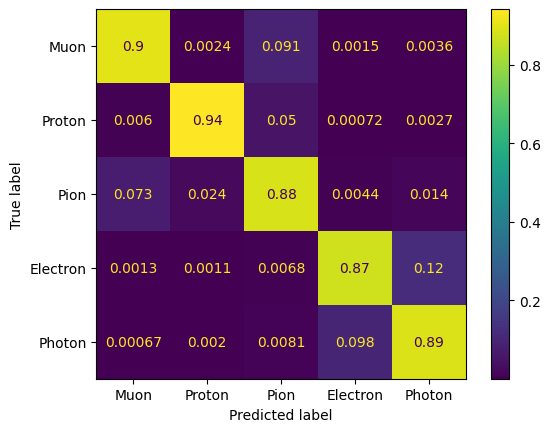

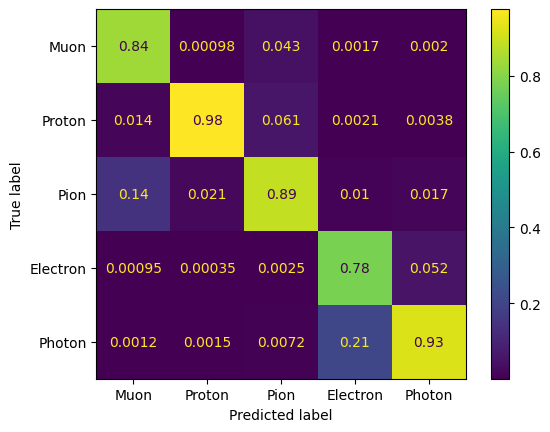

In [13]:
# Let's look at the confusion matrix

confMatrix = confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1))

trueSums = np.sum(confMatrix, axis=1)
predSums = np.sum(confMatrix, axis=0)

print('trueSums: ', trueSums)
print('predSums: ', predSums)

trueNormalised = np.zeros(shape=(nClasses, nClasses))
predNormalised = np.zeros(shape=(nClasses, nClasses))

for trueIndex in range(nClasses) : 
    for predIndex in range(nClasses) :
        nEntries = confMatrix[trueIndex][predIndex]
        if trueSums[trueIndex] > 0 :
            trueNormalised[trueIndex][predIndex] = float(nEntries) / float(trueSums[trueIndex])
        if predSums[predIndex] > 0 :
            predNormalised[trueIndex][predIndex] = float(nEntries) / float(predSums[predIndex])

displayTrueNorm = ConfusionMatrixDisplay(confusion_matrix=trueNormalised, display_labels=["Muon", "Proton", "Pion", "Electron", "Photon"])
displayTrueNorm.plot()

displayPredNorm = ConfusionMatrixDisplay(confusion_matrix=predNormalised, display_labels=["Muon", "Proton", "Pion", "Electron", "Photon"])
displayPredNorm.plot()

print(confMatrix)

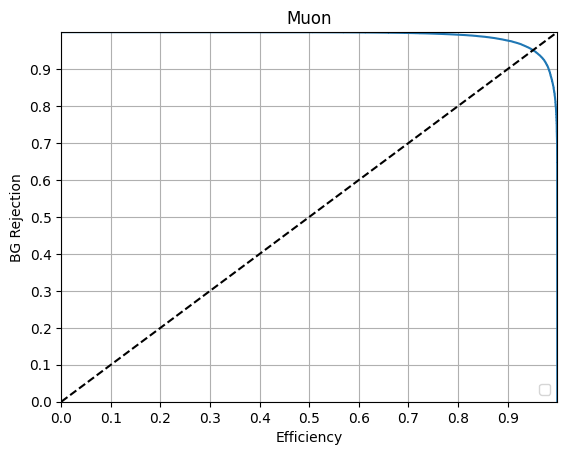

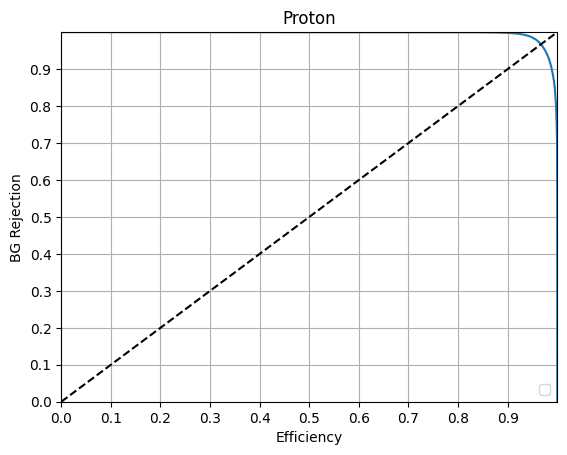

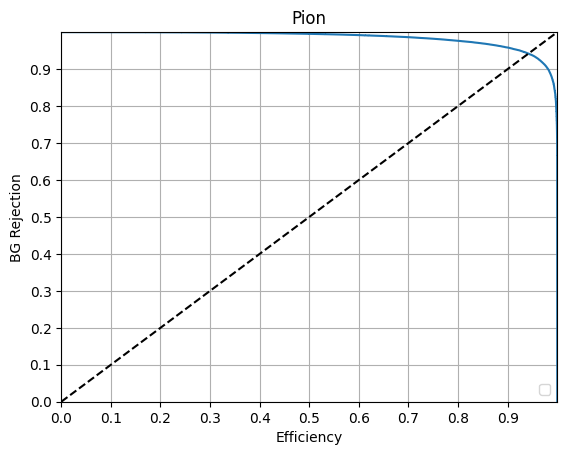

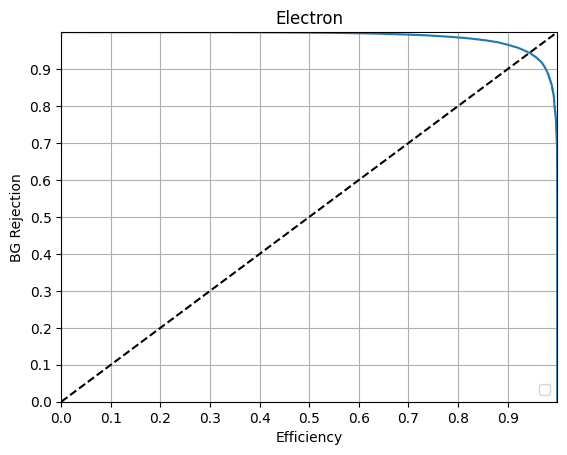

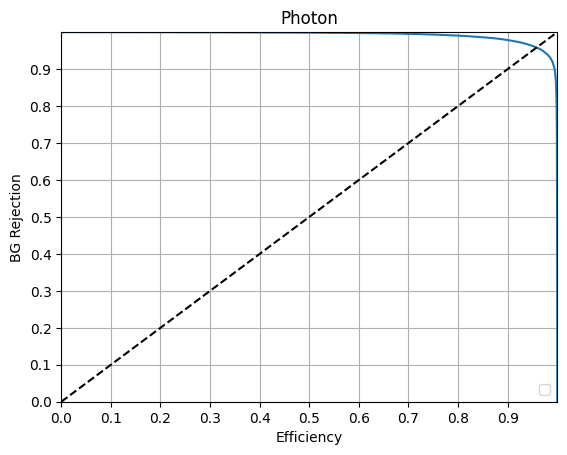

In [14]:
# Compute ROC curve and ROC area for each class

falsePositive = dict()
bkgRejection = dict()
truePositive = dict()
roc = dict()

for i in range(nClasses):
    falsePositive[i], truePositive[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    bkgRejection[i] = 1 - falsePositive[i]
    roc[i] = sklearn.metrics.auc(falsePositive[i], bkgRejection[i])

# Plot of a ROC curve for a specific class

rocCurveTitles = ["Muon", "Proton", "Pion", "Electron", "Photon", "Other"]

for i in range(nClasses):
    plt.figure()
    plt.plot(truePositive[i], bkgRejection[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xticks(np.arange(0, 1, 0.1))
    plt.yticks(np.arange(0, 1, 0.1))
    plt.xlabel('Efficiency')
    plt.ylabel('BG Rejection')
    plt.title(rocCurveTitles[i])
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

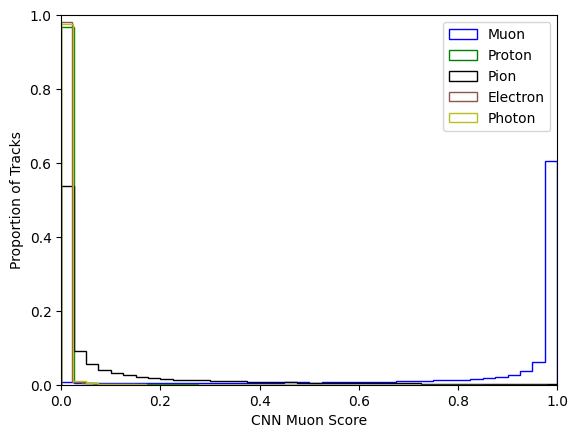

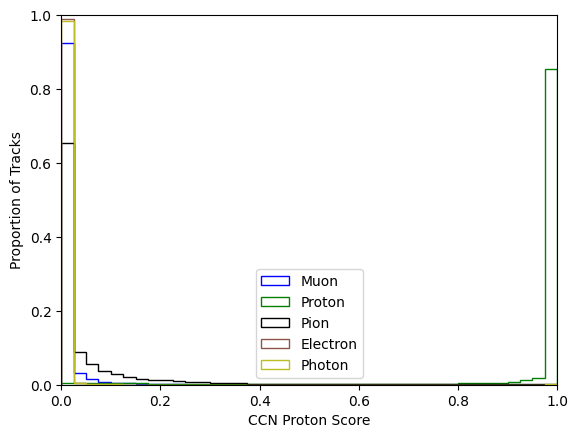

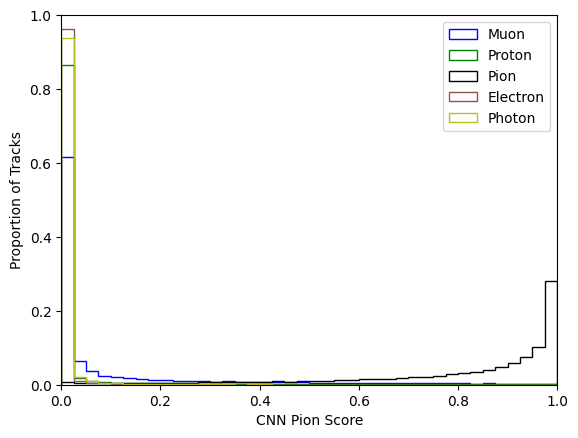

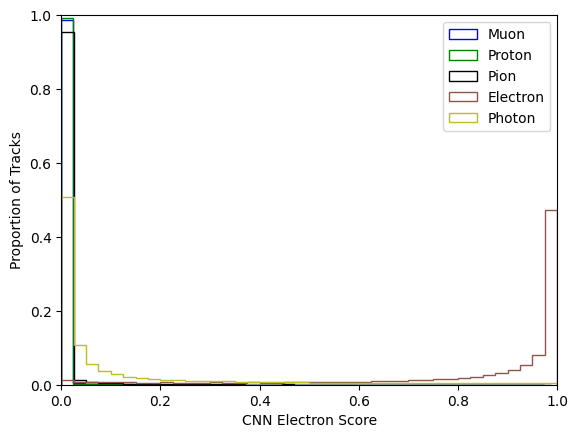

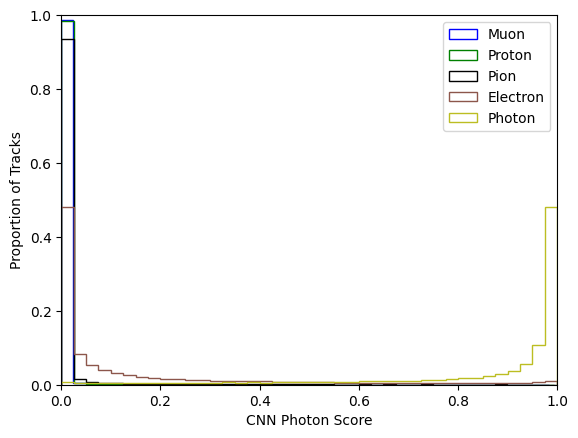

In [18]:
particleColors = ('b', 'g', 'k', 'tab:brown', 'tab:olive', 'tab:gray')
histTitles = ('CNN Muon Score', 'CCN Proton Score', 'CNN Pion Score', 'CNN Electron Score', 'CNN Photon Score', 'CNN Other Score')

for i in range(nClasses) :
    for j in range(nClasses) :
        nTrueParticles = trueSums[j]
        weights = np.full(nTrueParticles, 1.0/nTrueParticles)
        plt.hist(y_pred[y_test[:,j] == 1][:,i], bins=40, weights=weights, color=particleColors[j], histtype='step')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.0])
        plt.xlabel(histTitles[i])
        plt.ylabel('Proportion of Tracks')
        plt.legend(['Muon', 'Proton', 'Pion', 'Electron', 'Photon', 'Other'])
    plt.show()

In [16]:
incorrectIndicies = []

targetTruth = 3
targetPred = 4

for i in range (y_pred.shape[0]) :
    prediction = np.argmax(y_pred[i])
    truth = np.argmax(y_test[i])
    
    if ((prediction == targetPred) & (truth == targetTruth)):
        incorrectIndicies.append([i, prediction, truth])
    
print(incorrectIndicies)         

[[153, 4, 3], [337, 4, 3], [346, 4, 3], [441, 4, 3], [508, 4, 3], [782, 4, 3], [1576, 4, 3], [2142, 4, 3], [2668, 4, 3], [2781, 4, 3], [2901, 4, 3], [3078, 4, 3], [3121, 4, 3], [3223, 4, 3], [3307, 4, 3], [3425, 4, 3], [3495, 4, 3], [4015, 4, 3], [4020, 4, 3], [4045, 4, 3], [4081, 4, 3], [4118, 4, 3], [4166, 4, 3], [4520, 4, 3], [5514, 4, 3], [5640, 4, 3], [5820, 4, 3], [6464, 4, 3], [6679, 4, 3], [6824, 4, 3], [7389, 4, 3], [7621, 4, 3], [7749, 4, 3], [7931, 4, 3], [8258, 4, 3], [8298, 4, 3], [8495, 4, 3], [8678, 4, 3], [8849, 4, 3], [8908, 4, 3], [9122, 4, 3], [10025, 4, 3], [10091, 4, 3], [10358, 4, 3], [10446, 4, 3], [10722, 4, 3], [10904, 4, 3], [11043, 4, 3], [11052, 4, 3], [11355, 4, 3], [12002, 4, 3], [12735, 4, 3], [13222, 4, 3], [13264, 4, 3], [13313, 4, 3], [13609, 4, 3], [13787, 4, 3], [14652, 4, 3], [14899, 4, 3], [15117, 4, 3], [15298, 4, 3], [15321, 4, 3], [15806, 4, 3], [16185, 4, 3], [16327, 4, 3], [16518, 4, 3], [16905, 4, 3], [16940, 4, 3], [17091, 4, 3], [17268, 4, 

[0.03814287 0.08700739 0.8639264  0.00178867 0.00913461]


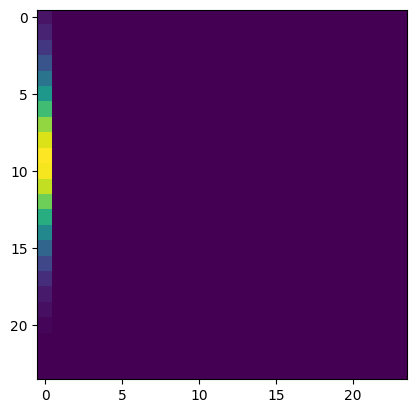

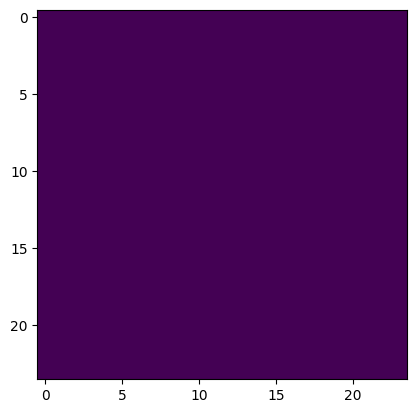

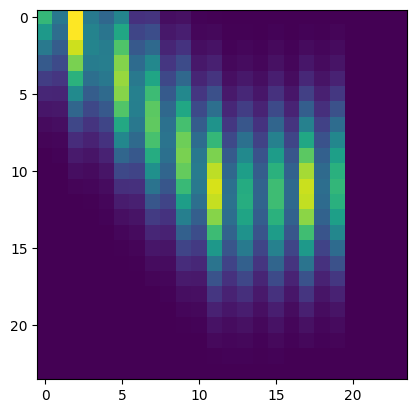

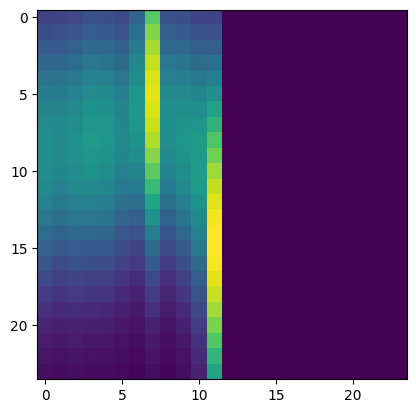

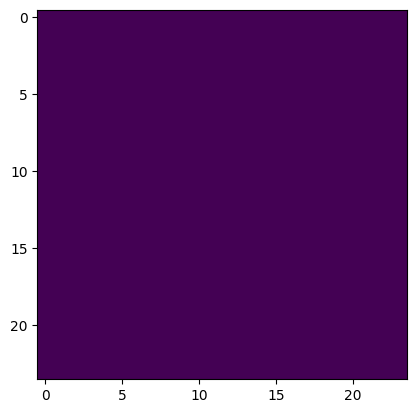

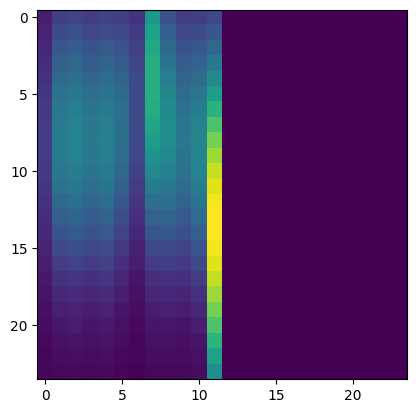

In [17]:
indexToView = 72838

print(y_pred[indexToView])

fig_startU, ax_startU = plt.subplots(1,1)
ax_startU.imshow(startGridU_calo_test[indexToView])

fig_startV, ax_startV = plt.subplots(1,1)
ax_startV.imshow(startGridV_calo_test[indexToView])

fig_startW, ax_startW = plt.subplots(1,1)
ax_startW.imshow(startGridW_calo_test[indexToView])
    
fig_endU, ax_endU = plt.subplots(1,1)
ax_endU.imshow(endGridU_calo_test[indexToView])

fig_enV, ax_endV = plt.subplots(1,1)
ax_endV.imshow(endGridV_calo_test[indexToView])

fig_endW, ax_endW = plt.subplots(1,1)
ax_endW.imshow(endGridW_calo_test[indexToView])